<a href="https://colab.research.google.com/github/nakthecoder/Online-Courses-Learning/blob/master/Group_Exercise_Agentic_AI_in_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
CSV_PATH = "mock_ad_performance.csv"

In [3]:
import pandas as pd

df = pd.read_csv(CSV_PATH)
display(df.head())

,date,channel,spend,impressions,clicks,conversions
0,2025-10-09,Display,137.38,52763,286,9
1,2025-10-09,Search,93.37,1874,69,2
2,2025-10-09,Social,69.25,3859,78,5
3,2025-10-10,Display,31.44,4862,46,1
4,2025-10-10,Search,144.50,3555,120,4


In [5]:
import numpy as np

# Configuration
TOTAL_DAILY_BUDGET = 300.0     # Total budget to allocate each day
CHANNELS = ["Search", "Social", "Display"]
PRIMARY_OBJECTIVE = "conversions"  # Or "clicks"
MIN_FLOOR = 0.10                # Minimum 10% for each channel
MAX_DAILY_SHIFT = 0.20          # Max +/- 20% shift per day
np.random.seed(42)


In [6]:
def propose_next_alloc(prev_alloc, day_perf):
    best_ch = max(day_perf, key=day_perf.get)
    alloc = prev_alloc.copy()
    inc = MAX_DAILY_SHIFT
    target_best = min(alloc[best_ch] + inc, 1.0 - MIN_FLOOR * (len(prev_alloc) - 1))
    delta = target_best - alloc[best_ch]
    if delta > 0:
        others = [c for c in alloc if c != best_ch]
        take_each = delta / len(others)
        for c in others:
            give = min(take_each, max(0.0, alloc[c] - MIN_FLOOR))
            alloc[c] -= give
        alloc[best_ch] = 1.0 - sum(alloc[c] for c in others)
    return alloc, best_ch

def format_reason(date_str, metric_name, best_ch, scores, old_alloc, new_alloc):
    changes = {c: round((new_alloc[c] - old_alloc[c]) * 100, 2) for c in new_alloc}
    return f"{date_str}: {best_ch} up due to higher {metric_name}. Scores={scores}, Changes={changes}"


In [7]:
df['date'] = pd.to_datetime(df['date'])
dates = sorted(df['date'].unique())
alloc_prev = {c: 1.0 / len(CHANNELS) for c in CHANNELS}

log = []

for date in dates:
    sub = df[df['date'] == date]
    scores = {}
    for ch in CHANNELS:
        ch_data = sub[sub['channel'] == ch]
        if PRIMARY_OBJECTIVE == "conversions":
            val = ch_data['conversions'].sum() / max(ch_data['clicks'].sum(), 1)
            metric_name = "CVR"
        else:
            val = ch_data['clicks'].sum() / max(ch_data['impressions'].sum(), 1)
            metric_name = "CTR"
        scores[ch] = val

    new_alloc, best_ch = propose_next_alloc(alloc_prev, scores)
    reason = format_reason(str(date.date()), metric_name, best_ch, scores, alloc_prev, new_alloc)
    log.append({"date": str(date.date()), "best_channel": best_ch, "alloc": new_alloc, "reason": reason})
    alloc_prev = new_alloc

pd.DataFrame(log)


,date,best_channel,alloc,reason
0,2025-10-09,Social,"{'Search': 0.2333333333333333, 'Social': 0.533...",2025-10-09: Social up due to higher CVR. Score...
1,2025-10-10,Search,"{'Search': 0.43333333333333335, 'Social': 0.43...",2025-10-10: Search up due to higher CVR. Score...
2,2025-10-11,Search,"{'Search': 0.5666666666666665, 'Social': 0.333...",2025-10-11: Search up due to higher CVR. Score...
3,2025-10-12,Search,"{'Search': 0.6666666666666666, 'Social': 0.233...",2025-10-12: Search up due to higher CVR. Score...
4,2025-10-13,Search,"{'Search': 0.7333333333333333, 'Social': 0.166...",2025-10-13: Search up due to higher CVR. Score...
5,2025-10-14,Search,"{'Search': 0.7666666666666667, 'Social': 0.133...",2025-10-14: Search up due to higher CVR. Score...
6,2025-10-15,Display,"{'Search': 0.6666666666666667, 'Social': 0.1, ...",2025-10-15: Display up due to higher CVR. Scor...
7,2025-10-16,Search,"{'Search': 0.7333333333333334, 'Social': 0.1, ...",2025-10-16: Search up due to higher CVR. Score...
8,2025-10-17,Search,"{'Search': 0.7666666666666667, 'Social': 0.1, ...",2025-10-17: Search up due to higher CVR. Score...
9,2025-10-18,Search,"{'Search': 0.7833333333333333, 'Social': 0.1, ...",2025-10-18: Search up due to higher CVR. Score...


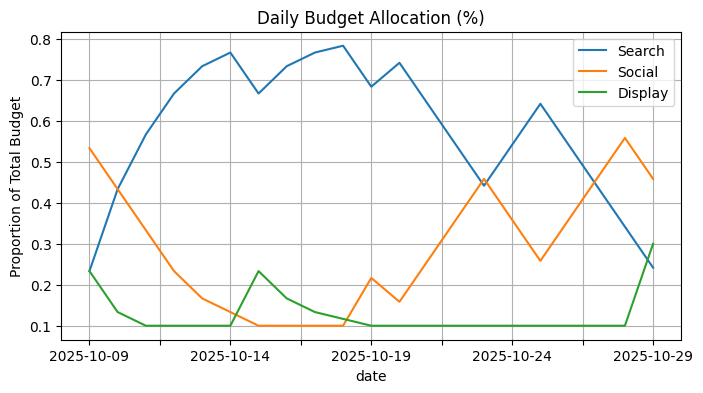

In [8]:
import matplotlib.pyplot as plt

alloc_history = pd.DataFrame([{**r["alloc"], "date": r["date"]} for r in log])
alloc_history.set_index("date").plot(figsize=(8,4))
plt.title("Daily Budget Allocation (%)")
plt.ylabel("Proportion of Total Budget")
plt.grid(True)
plt.show()
